# Rare-mode mechanism: posterior worlds versus decision worlds

This notebook is the human-readable record for candidate Paper Figure 1. The reusable mathematics and experiment engine live in `src/decision_tilt/`.

## 1. Question

Can a rare but high-utility predictive mode make finite posterior Monte Carlo select the wrong BO candidate even when the acquisition mean is evaluated stably in log space?

## 2. Why it matters to the paper

The paper's central diagnostic is a statistical mismatch, not floating-point underflow: posterior draws come from $P$, while acquisition value is controlled by $\Pi_x \propto P U_x$. A visibly wrong finite-sample acquisition mode would establish this mechanism before any decision-adapted sampler is considered.

## 3. Mathematics

For improvement $U=(Y-f^\star)_+$ under $Y\sim\mathcal N(\mu,\sigma^2)$, the implementation uses the exact first and second truncated moments from `PAPER_PLAN.md`. Mixture moments are component-weighted sums. Therefore

$$\chi^2(\Pi_x\Vert P_x)=\frac{E[U^2]}{E[U]^2}-1, \qquad \operatorname{RelVar}(\widehat{EI}_N)=\frac{\chi^2}{N}, \qquad ESS/N=\frac{1}{1+\chi^2}.$$

The utility-tilted component probabilities are $\widetilde w_k=w_k EI_k/EI$. Every finite-sample LogEI curve uses a log-sum-exp over positive sample utilities; this stabilizes arithmetic but cannot create an unsampled rare world. The positive control replaces improvement with $\tau\log(1+\exp((Y-f^\star)/\tau))$ and computes its exact reference moments by deterministic one-dimensional quadrature.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'PAPER_PLAN.md').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from decision_tilt.rare_mode import RareModeConfig, mixture_at, run_experiment

CONFIG_PATH = ROOT / 'experiments' / 'rare_mode_mechanism' / 'config.json'
OUTPUT_DIR = ROOT / 'experiments' / 'rare_mode_mechanism' / 'outputs'
config = RareModeConfig.load(CONFIG_PATH)
print('Protocol:', config.raw['protocol_version'])
print('Config hash:', config.config_hash)

Protocol: rare-mode-mechanism-v1
Config hash: 957cbc939405efb7bd2d95770aa57442099dd3c40917d56af83665f7dc6896e6


## 4. Frozen protocol

Parameters were frozen from analytical moments before repeated sampling: rare weight 0.005, incumbent 0, common-mode center $x_A=-0.75$, rare-mode center $x_B=0.85$, standard deviations 0.04 and 0.20, and positive-control temperature 0.01. The JSON contract records every mean-function parameter, seed, sample count, repetition count, and prospective threshold. No parameter was changed after reliability results were observed.

In [2]:
rows = []
for label, location in [('A', config.model['candidate_a']), ('B', config.model['candidate_b'])]:
    mixture = mixture_at(location, config)
    raw_first, raw_second = mixture.improvement_moments(config.model['incumbent'])
    smooth_first, smooth_second = mixture.softplus_moments(
        config.model['incumbent'], config.model['smooth_temperature'],
        order=config.numerics['gauss_hermite_order'])
    rows.append({
        'candidate': label, 'x': location, 'exact_EI': raw_first,
        'chi_square': raw_second / raw_first**2 - 1,
        'ESS_fraction': raw_first**2 / raw_second,
        'tilted_rare_weight': mixture.tilted_component_weights(config.model['incumbent'])[1],
        'smooth_acquisition': smooth_first,
        'smooth_chi_square': smooth_second / smooth_first**2 - 1,
    })
pd.DataFrame(rows)

,candidate,x,exact_EI,chi_square,ESS_fraction,tilted_rare_weight,smooth_acquisition,smooth_chi_square
0,A,-0.75,0.027788,1.147898,0.465572,0.000582,0.029161,0.976517
1,B,0.85,0.035000,199.163265,0.004996,1.000000,0.035000,199.163260


## 5. GO / NO-GO expectation

The frozen gate requires at least a 20% raw-EI advantage and 10% positive-control advantage at $x_B$, ESS fraction at most 1%, at least 99% rare-component mass after tilting, iid variance agreement within 10%, frequent iid and scrambled-Sobol misranking at $N=512$, survival under positive smoothing, and eventual iid recovery by $N=8192$. A failed check is reported as a NO-GO; the mixture is not retuned.

## 6. Experiment

Run the complete frozen CPU protocol. It uses 10,000 iid repetitions and 1,024 independent scrambled Sobol scrambles at each power-of-two sample count from 32 through 8,192. Common base randomness is used across the two candidates, which strengthens rather than handicaps both estimators.

In [3]:
summary = run_experiment(CONFIG_PATH, OUTPUT_DIR)
print(json.dumps(summary['gate'], indent=2))
print(f"CPU runtime: {summary['runtime_seconds']:.2f} seconds")

{
  "protocol_version": "rare-mode-mechanism-v1",
  "config_hash": "957cbc939405efb7bd2d95770aa57442099dd3c40917d56af83665f7dc6896e6",
  "status": "GO_EXPECTATIONS_MET",
  "checks": {
    "raw_ei_margin": true,
    "smooth_margin": true,
    "large_decision_shift": true,
    "rare_mode_dominates_tilt": true,
    "iid_variance_identity": true,
    "iid_raw_failure_at_512": true,
    "qmc_raw_failure_at_512": true,
    "smooth_failure_at_512": true,
    "eventual_iid_recovery": true
  },
  "observed": {
    "raw_ei_ratio_b_over_a": 1.2595148802167493,
    "smooth_ratio_b_over_a": 1.2002526601686723,
    "candidate_b_ess_fraction": 0.004995921697037181,
    "candidate_b_tilted_rare_weight": 0.999999999953627,
    "maximum_iid_raw_variance_relative_error": 0.03155996992948185,
    "iid_raw_accuracy_at_512": 0.5627,
    "qmc_raw_accuracy_at_512": 0.5947265625,
    "iid_smooth_accuracy_at_512": 0.4899,
    "iid_raw_accuracy_at_8192": 0.9102
  }
}
CPU runtime: 13.08 seconds


## 7. Figures

Panel A contrasts ordinary and utility-tilted worlds. Panel B shows stable finite-sample LogEI landscapes. Panel C verifies the exact iid variance law and shows scrambled-Sobol behavior as a control. Panel D reports decision reliability for raw and strictly positive utilities.

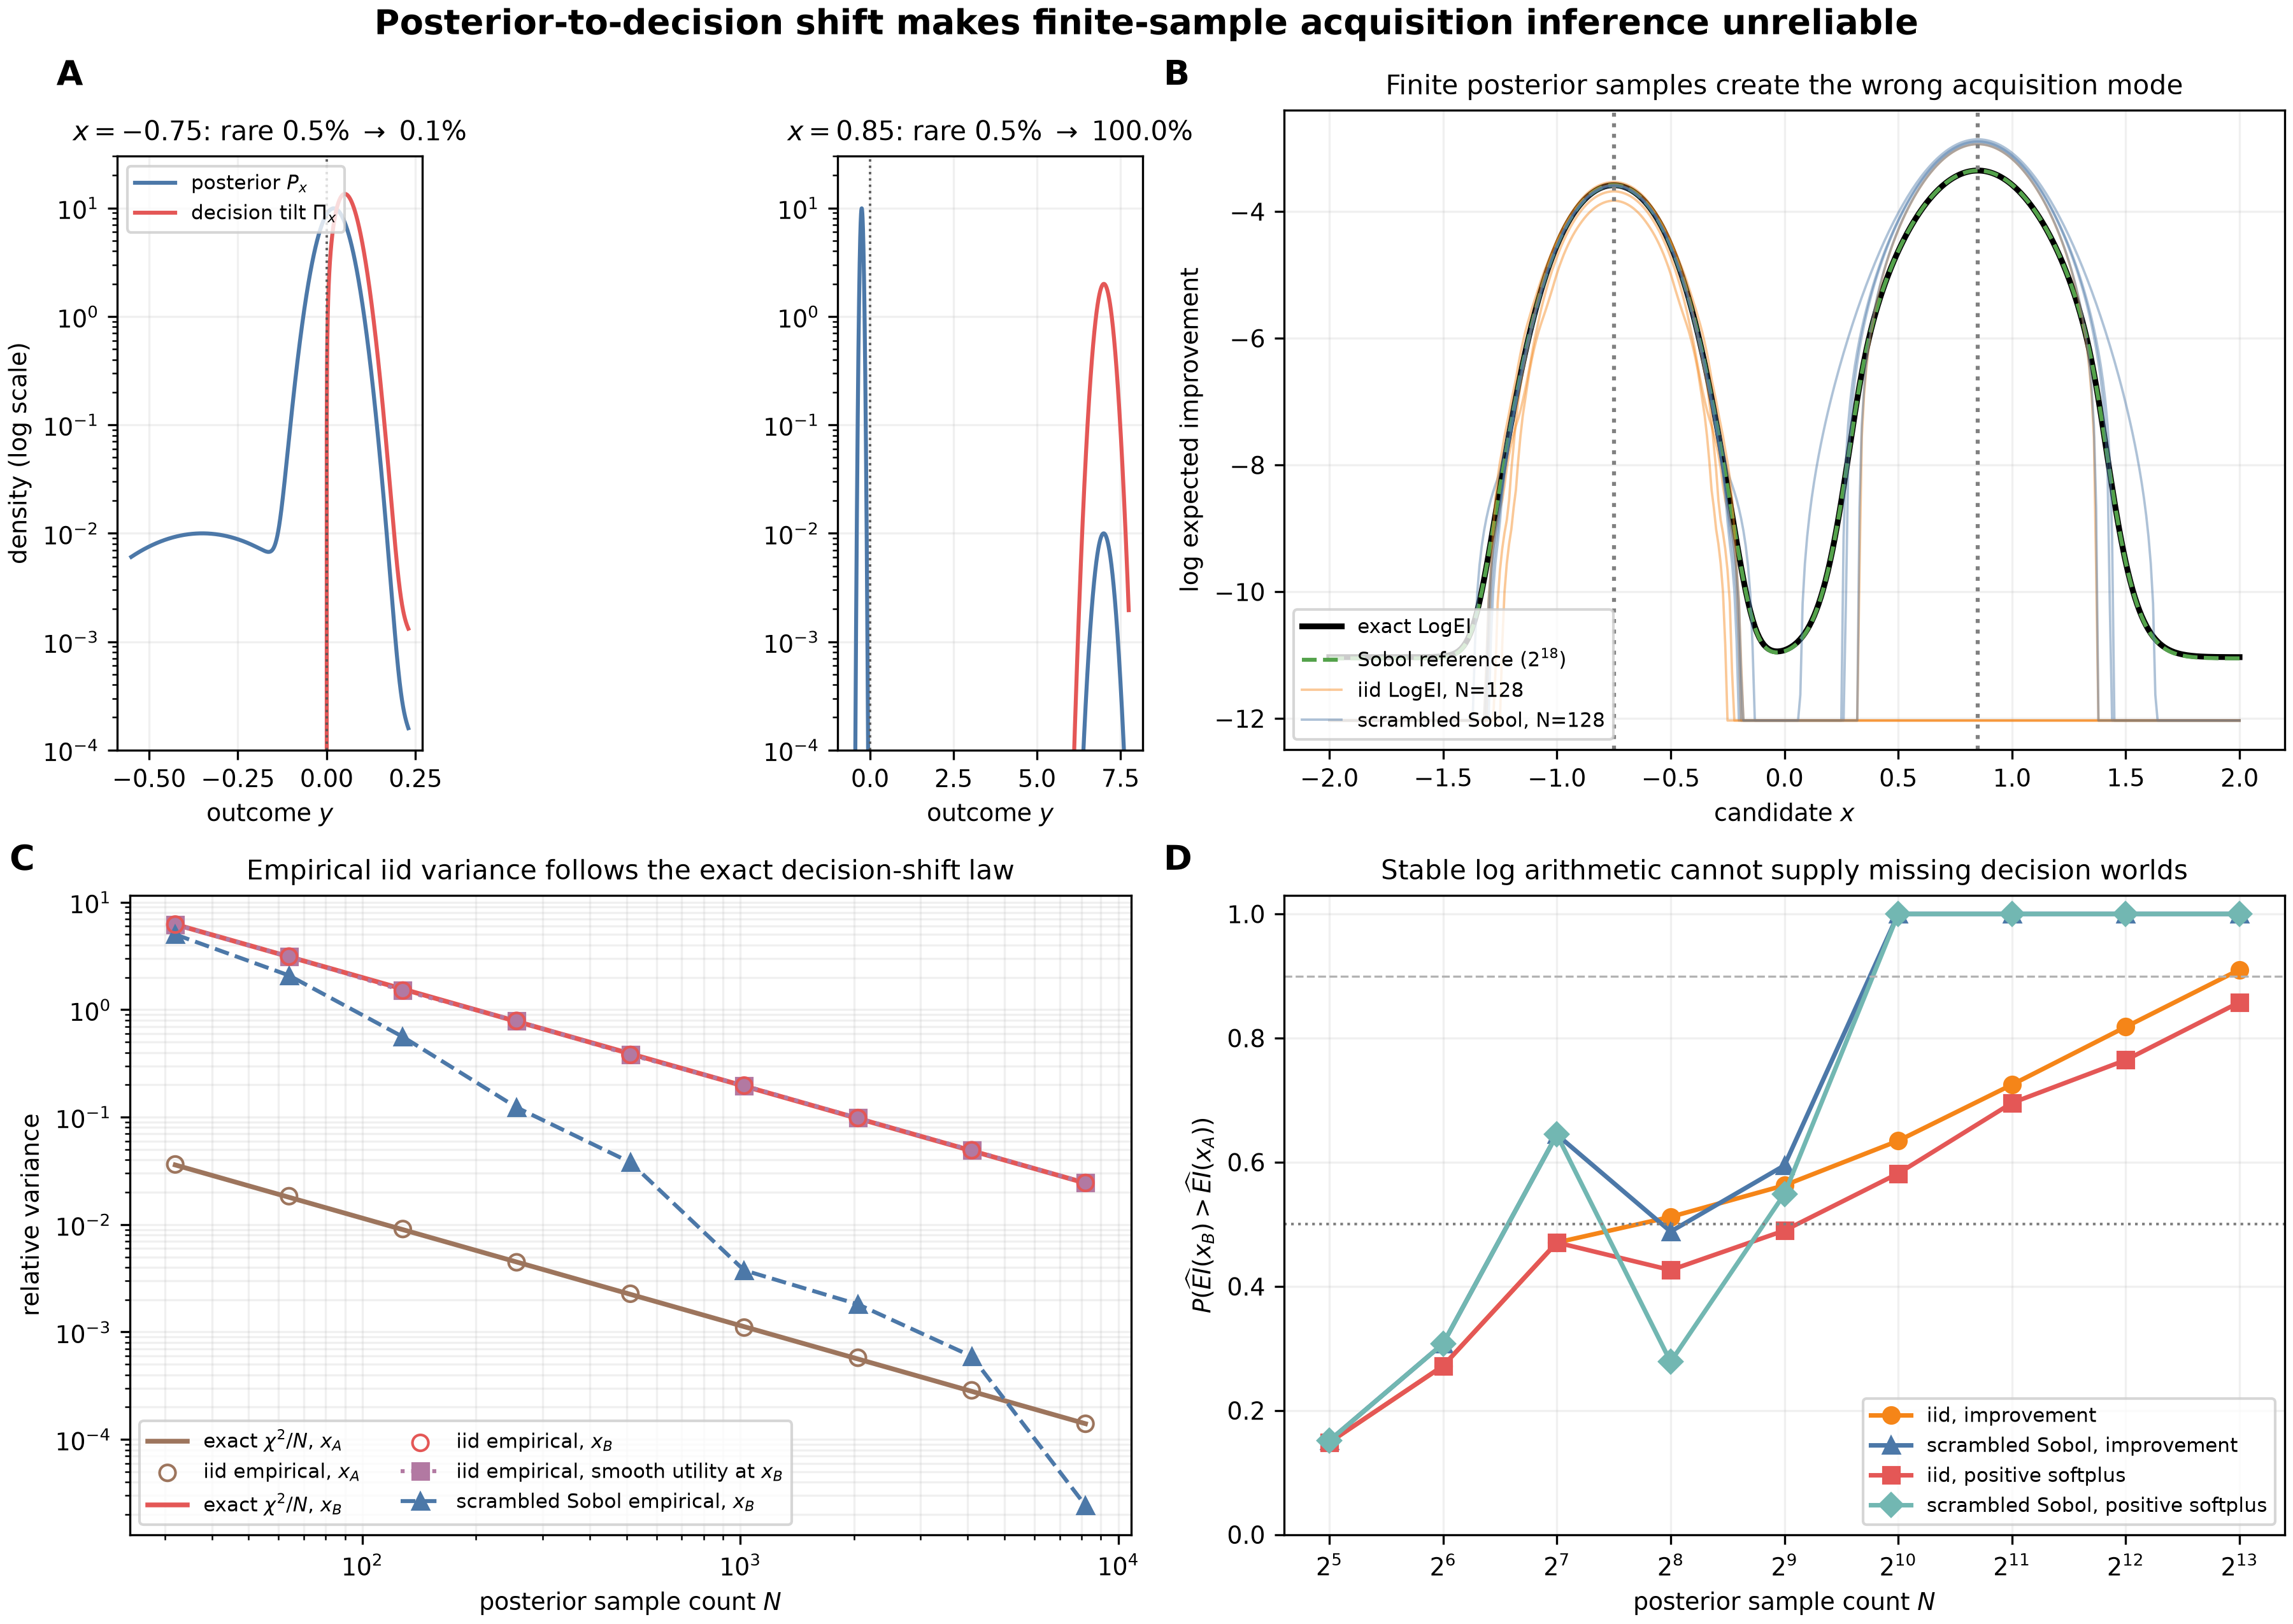

In [4]:
display(Image(filename=str(OUTPUT_DIR / 'figure1_rare_mode_mechanism.png'), width=1100))

## 8. Numerical summary

In [5]:
ranking = pd.read_csv(OUTPUT_DIR / 'ranking_results.csv')
display(ranking[ranking.sample_count.isin([128, 256, 512, 1024, 8192])].pivot(
    index='sample_count', columns=['method', 'utility'], values='ranking_accuracy'))
display(pd.DataFrame([summary['gate']['observed']]).T.rename(columns={0: 'value'}))

method           iid               qmc          
utility          raw  smooth       raw    smooth
sample_count                                    
128           0.4706  0.4706  0.644531  0.644531
256           0.5119  0.4262  0.488281  0.278320
512           0.5627  0.4899  0.594727  0.548828
1024          0.6345  0.5819  1.000000  1.000000
8192          0.9102  0.8577  1.000000  1.000000

,value
raw_ei_ratio_b_over_a,1.259515
smooth_ratio_b_over_a,1.200253
candidate_b_ess_fraction,0.004996
candidate_b_tilted_rare_weight,1.000000
maximum_iid_raw_variance_relative_error,0.031560
iid_raw_accuracy_at_512,0.562700
qmc_raw_accuracy_at_512,0.594727
iid_smooth_accuracy_at_512,0.489900
iid_raw_accuracy_at_8192,0.910200


## 9. Interpretation

The constructed mechanism is strong and quantitatively explained by decision shift. The rare candidate is exactly 25.95% better for EI, yet at 512 worlds the correct-ranking probability is only 56.27% for iid and 59.47% for scrambled Sobol. The positive softplus control is only 48.99%, so literal zero utility is not the explanation. IID variance follows $\chi^2/N$ within 3.16%, and 91.02% iid reliability requires 8,192 worlds. Scrambled Sobol reaches 100% at 1,024 because one-dimensional stratification controls the rare-component count; this is an important baseline strength, not a failure to report.

This is deliberately synthetic mechanism evidence. It does not establish that such shifts occur naturally near useful decisions, that 1,024 QMC worlds are expensive, or that adapting a proposal beats QMC wall-clock.

## 10. Next authorized action

Stop for human review of Figure 1 and the mechanism gate. This notebook does **not** authorize `constrained_batch_shift` or any decision-adapted sampler.